In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/workspace /content/

Mounted at /content/drive


In [ ]:
!dir /content/workspace

checkpoints		    corrections_test   outputs
corrections_seg_test.json   corrections_train
corrections_seg_train.json  logs


# Pre-requisite

In [ ]:
!pip install kaggle -q
!pip install albumentations -q

# Build folder structure and Unzip dataset

In [ ]:
!kaggle datasets download -d puneet6060/intel-image-classification


Dataset URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
License(s): copyright-authors
100% 346M/346M [00:09<00:00, 38.2MB/s]



```
/content/
├── dataset/
└── workspace/
    ├── checkpoints/
    ├── logs/
    └── outputs/
```

In [ ]:
!mkdir /content/dataset
!mkdir -p /content/workspace/{checkpoints,logs,outputs}

In [ ]:
!unzip -q intel-image-classification.zip -d /content/dataset/intel-image-classification

In [ ]:
!dir /content/dataset/intel-image-classification/

seg_pred  seg_test  seg_train


# Part 2 - Transfer Learning & Fine-Tuning

## 2.1 - Baseline model

In [ ]:
import torch
import torch.nn as nn

class LightweightCNN(nn.Module):
    def __init__(self, num_classes=6, base_channels=32):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )

        b = base_channels
        self.features = nn.Sequential(
            conv_block(  3,   b),   # (B,   b, 112, 112)
            conv_block(  b, b*2),   # (B, b*2,  56,  56)
            conv_block(b*2, b*4),   # (B, b*4,  28,  28)
            conv_block(b*4, b*8),   # (B, b*8,  14,  14)
            conv_block(b*8,b*16),   # (B,b*16,   7,   7)
        )

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(b*16, b*8),
            nn.ReLU(inplace=True),
            nn.Dropout(0.1),
            nn.Linear(b*8, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

### Functions for training, visualization, and evaluation



In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader

import json
import time

import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import seaborn as sns
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, f1_score

import os
import numpy as np
from PIL import Image

class IntelDataset(Dataset):
    def __init__(self, split, data_dir, transform=None, use_synthetic=False):
        self.transform = transform
        self.samples = []
        self.classes = sorted(os.listdir(os.path.join(data_dir, split, split)))
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

        split_path = os.path.join(data_dir, split, split)
        for cls in self.classes:
            cls_path = os.path.join(split_path, cls)
            if os.path.isdir(cls_path):
                for img_file in os.listdir(cls_path):
                    if not use_synthetic and img_file.startswith('synthetic_'):
                        continue
                    self.samples.append((os.path.join(cls_path, img_file), self.class_to_idx[cls]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = np.array(Image.open(img_path).convert('RGB'))
        if self.transform:
            img = self.transform(image=img)['image']
        return img, label


def train_step(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += imgs.size(0) # batch

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += imgs.size(0)

    return total_loss / total, correct / total


def train(model, train_loader, test_loader, num_epochs=30, lr=1e-3, resume=False):
    device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    model     = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs)

    best_val_acc = 0.0
    start_epoch  = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': [], 'epoch_time': []}


    # resume from checkpoint
    if resume and os.path.exists(ckpt_path):
        checkpoint = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(checkpoint['model'])
        optimizer.load_state_dict(checkpoint['optimizer'])
        scheduler.load_state_dict(checkpoint['scheduler'])
        best_val_acc = checkpoint['best_val_acc']
        start_epoch  = checkpoint['epoch'] + 1
        history      = checkpoint['history']
        print(f"Resumed from epoch {start_epoch}, best val acc: {best_val_acc:.4f}")

    start_time = time.time()
    for epoch in range(start_epoch, start_epoch + num_epochs):
        epoch_start = time.time()

        train_loss, train_acc = train_step(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, test_loader, criterion, device)
        scheduler.step()

        epoch_time = time.time() - epoch_start

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(optimizer.param_groups[0]['lr'])
        history['epoch_time'].append(epoch_time)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                'epoch'       : epoch,
                'model'       : model.state_dict(),
                'optimizer'   : optimizer.state_dict(),
                'scheduler'   : scheduler.state_dict(),
                'best_val_acc': best_val_acc,
                'history'     : history,
            }, ckpt_path)

        print(f"Epoch [{epoch+1:02d}/{start_epoch + num_epochs}] "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | "
              f"Time: {epoch_time:.1f}s "
              f"{'★' if val_acc == best_val_acc else ''}")

    total_time = time.time() - start_time
    history['total_time'] = total_time
    print(f"\nTotal training time: {total_time:.1f}s ({total_time/60:.1f} min)")
    print(f"\nBest Val Acc: {best_val_acc:.4f}")

    # save history
    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"History saved: {history_path}")

    return history

def plot_history(history, experiment_name):
    epochs = range(1, len(history['train_loss']) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), dpi=150)
    fig.suptitle('Training History', fontsize=14, fontweight='bold')

    # loss
    axes[0].plot(epochs, history['train_loss'], label='Train', color='steelblue')
    axes[0].plot(epochs, history['val_loss'],   label='Val',   color='coral')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # accuracy
    axes[1].plot(epochs, history['train_acc'], label='Train', color='steelblue')
    axes[1].plot(epochs, history['val_acc'],   label='Val',   color='coral')
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    # lr
    axes[2].plot(epochs, history['lr'], color='seagreen')
    axes[2].set_title('Learning Rate', fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('LR')
    axes[2].grid(alpha=0.3)

    for ax in axes:
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))

    plt.tight_layout()
    plt.savefig(os.path.join('/content/workspace/outputs', f'{experiment_name}_history.png'), bbox_inches='tight')
    plt.show()

def evaluate_full(model, loader, class_names):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.eval()

    all_preds, all_labels, all_imgs, all_probs = [], [], [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)
            preds   = outputs.argmax(dim=1)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            all_imgs.append(imgs.cpu())
            all_probs.append(probs.cpu())

    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    all_imgs   = torch.cat(all_imgs)
    all_probs  = torch.cat(all_probs).numpy()

    return all_preds, all_labels, all_imgs, all_probs

def show_misclassified(all_imgs, all_preds, all_labels, all_probs, class_names, experiment_name='exp', n=5):
    mean = torch.tensor(list(DATASET_MEAN)).view(3, 1, 1)
    std  = torch.tensor(list(DATASET_STD)).view(3, 1, 1)

    wrong_idx = np.where(all_preds != all_labels)[0]
    # pick n with highest confidence — most interesting failure cases
    wrong_conf = all_probs[wrong_idx, all_preds[wrong_idx]]
    top_idx    = wrong_idx[np.argsort(wrong_conf)[::-1][:n]]

    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), dpi=150)
    fig.suptitle(f'Misclassified Examples (High Confidence)\nModel - {experiment_name}', fontsize=14, fontweight='bold')

    for ax, idx in zip(axes, top_idx):
        img = all_imgs[idx] * std + mean
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()

        gt   = class_names[all_labels[idx]]
        pred = class_names[all_preds[idx]]
        conf = all_probs[idx, all_preds[idx]]

        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f'GT: {gt}\nPred: {pred}\nConf: {conf:.2f}', fontsize=9,
                     color='red' if gt != pred else 'green')

    plt.tight_layout()
    plt.savefig(os.path.join('/content/workspace/outputs', f'{experiment_name}_misclassified.png'), bbox_inches='tight')
    plt.show()

def visualize_eval(all_preds, all_labels, all_imgs, all_probs, class_names, experiment_name='exp'):
    # per-class metrics
    precision, recall, f1, support = precision_recall_fscore_support(all_labels, all_preds, average=None)
    acc_per_class = [
        (all_preds[all_labels == i] == i).mean()
        for i in range(len(class_names))
    ]

    # macro F1 score
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    # create a table for metrics and save as an image
    data = []
    for i, cls in enumerate(class_names):
        # Calculate accuracy for this specific class
        mask = (all_labels == i)
        acc = (all_preds[mask] == i).mean() if mask.any() else 0.0

        # Format as percentage strings
        data.append([
            cls,
            f"{acc:.1%}",
            f"{precision[i]:.1%}",
            f"{recall[i]:.1%}",
            f"{f1[i]:.1%}",
            int(support[i])
        ])

    data.append([
        "MACRO AVG",
        "-", "-", "-",
        f"{macro_f1:.1%}",
        int(np.sum(support))
    ])

    columns = ['Class', 'Acc', 'Prec', 'Recall', 'F1', 'Count']

    fig, ax = plt.subplots(figsize=(10, 4), dpi=150)
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2.0)

    for (row, col), cell in table.get_celld().items():
        if row == 0 or row == len(data):
            cell.set_text_props(weight='bold')
        if row == 0:
            cell.set_facecolor('#E6E6E6')

    ax.set_title(f'Performance Metrics (Macro F1: {macro_f1:.2%})\nModel - {experiment_name}',
                 fontsize=12, fontweight='bold', pad=25)

    # Save and Show
    os.makedirs('/content/workspace/outputs', exist_ok=True)
    save_path = os.path.join('/content/workspace/outputs', f'{experiment_name}_metrics_pct.png')
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_title(f'Confusion Matrix\nModel - {experiment_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Ground Truth')
    plt.tight_layout()
    plt.savefig(os.path.join('/content/workspace/outputs', f'{experiment_name}_confusion_matrix.png'), bbox_inches='tight')
    plt.show()

### Train the baseline model

In [ ]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

data_dir = '/content/dataset/intel-image-classification'

# from seg_train
DATASET_MEAN = (0.4302, 0.4575, 0.4538)
DATASET_STD = (0.2694, 0.2679, 0.2983)

# transform
train_transform = A.Compose([
    A.Resize(224, 224),
    # Color / Photometric transform
    A.RandomBrightnessContrast(p=0.3),
    A.HueSaturationValue(p=0.3),
    # Regularization-style transform
    A.CoarseDropout(num_holes_range=(1, 8),
                    hole_height_range=(8, 16),
                    hole_width_range=(8, 16),
                    p=0.3),
    # Geometric transform
    A.HorizontalFlip(p=0.5),
    #A.VerticalFlip(p=0.1),
    A.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0), p=1.0),
    A.Affine(translate_percent=0.05,
             scale=(0.9, 1.3),
             rotate=(-15, 15),
             p=0.5),
    # Normalization and Tensor Converison
    A.Normalize(mean=DATASET_MEAN,
                std=DATASET_STD),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(mean=DATASET_MEAN,
                std=DATASET_STD),
    ToTensorV2()
])

# model
model = LightweightCNN(num_classes=6, base_channels=32)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

# dataset
train_dataset = IntelDataset('seg_train', data_dir, transform=train_transform, use_synthetic=False)
test_dataset  = IntelDataset('seg_test', data_dir, transform=val_transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# experiment configuration
experiment_name = 'cnn_baseline'

ckpt_path    = os.path.join('/content/workspace/checkpoints', f'{experiment_name}_best.pth')
history_path = os.path.join('/content/workspace/logs',        f'{experiment_name}_history.json')
plot_path    = os.path.join('/content/workspace/outputs',     f'{experiment_name}_history.png')

# training
history = train(model, train_loader, test_loader, num_epochs=100, resume=False)

Total parameters: 1,702,438
Using device: cuda
Epoch [01/100] Train Loss: 1.0292 Acc: 0.5837 | Val Loss: 0.7225 Acc: 0.7323 | Time: 35.3s ★
Epoch [02/100] Train Loss: 0.7580 Acc: 0.7141 | Val Loss: 0.7264 Acc: 0.7270 | Time: 34.1s 
Epoch [03/100] Train Loss: 0.6633 Acc: 0.7529 | Val Loss: 0.7111 Acc: 0.7393 | Time: 34.6s ★
Epoch [04/100] Train Loss: 0.5983 Acc: 0.7793 | Val Loss: 0.5219 Acc: 0.8193 | Time: 34.9s ★
Epoch [05/100] Train Loss: 0.5745 Acc: 0.7846 | Val Loss: 0.5330 Acc: 0.8043 | Time: 35.4s 
Epoch [06/100] Train Loss: 0.5388 Acc: 0.8013 | Val Loss: 0.4959 Acc: 0.8253 | Time: 35.5s ★
Epoch [07/100] Train Loss: 0.5066 Acc: 0.8208 | Val Loss: 0.4354 Acc: 0.8500 | Time: 35.6s ★
Epoch [08/100] Train Loss: 0.4946 Acc: 0.8197 | Val Loss: 0.3842 Acc: 0.8653 | Time: 35.8s ★
Epoch [09/100] Train Loss: 0.4671 Acc: 0.8306 | Val Loss: 0.3968 Acc: 0.8517 | Time: 36.1s 
Epoch [10/100] Train Loss: 0.4460 Acc: 0.8373 | Val Loss: 0.5276 Acc: 0.8230 | Time: 36.0s 
Epoch [11/100] Train Loss: 

### Evaluate the best model

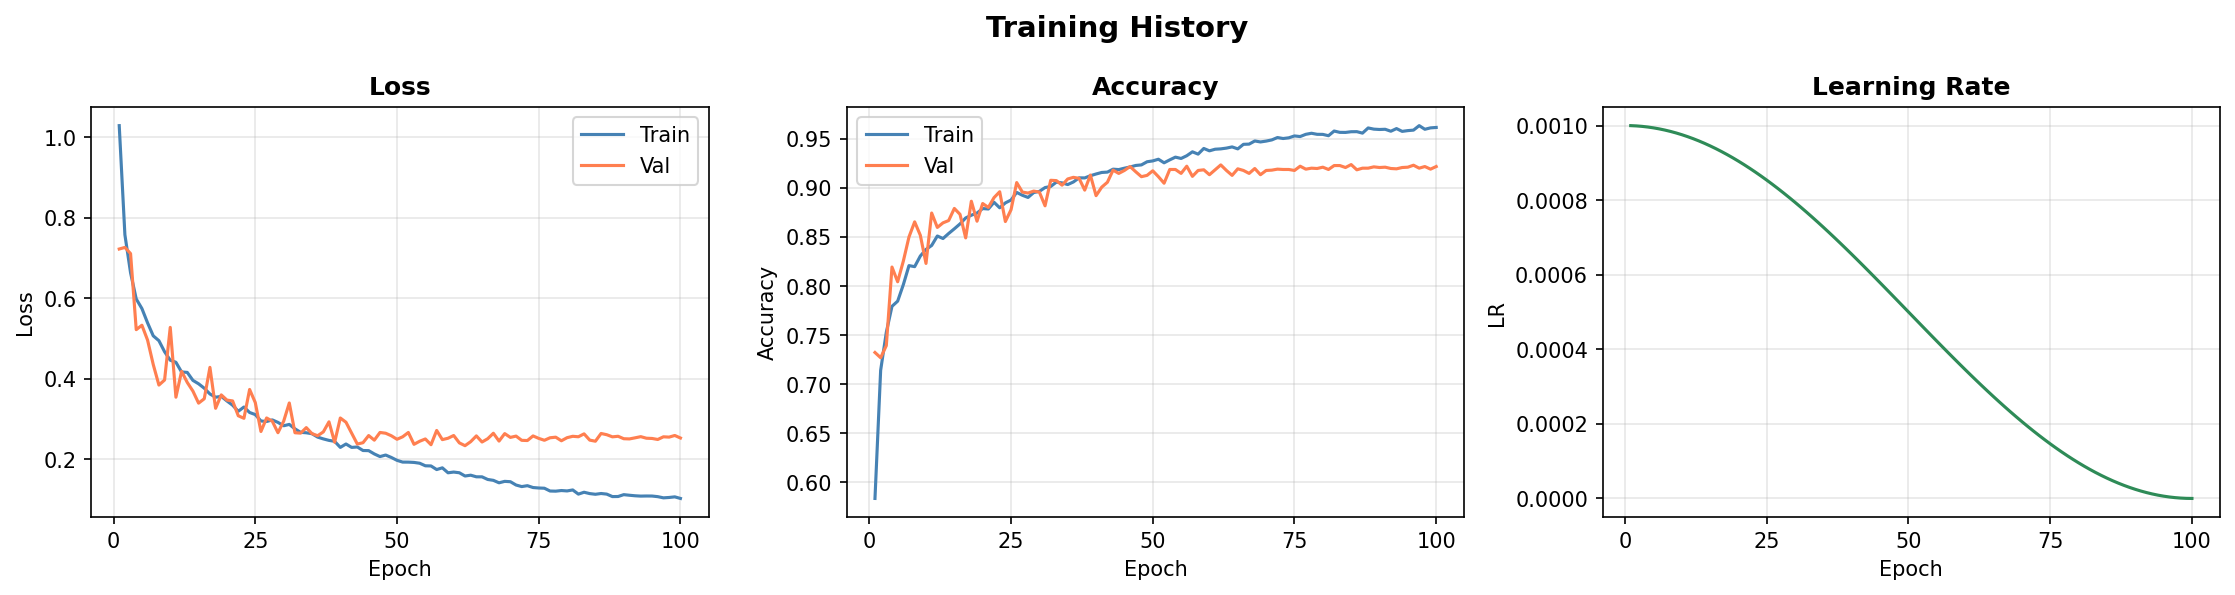

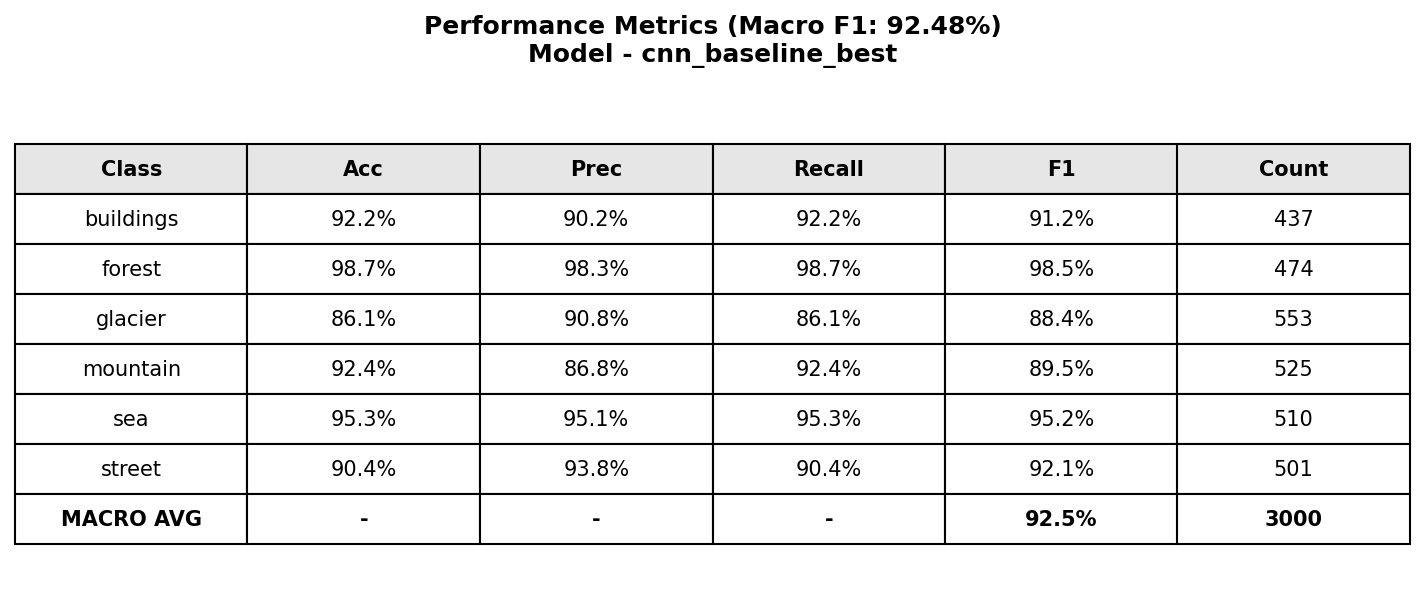

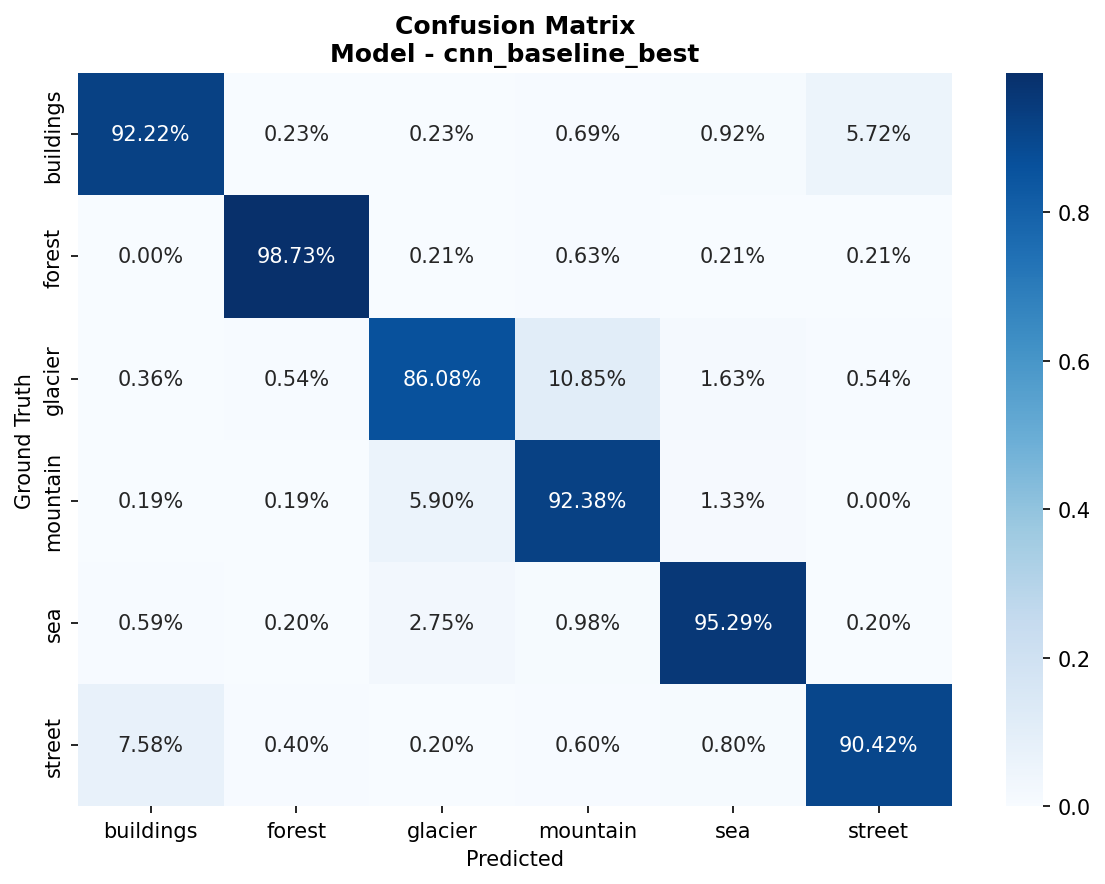

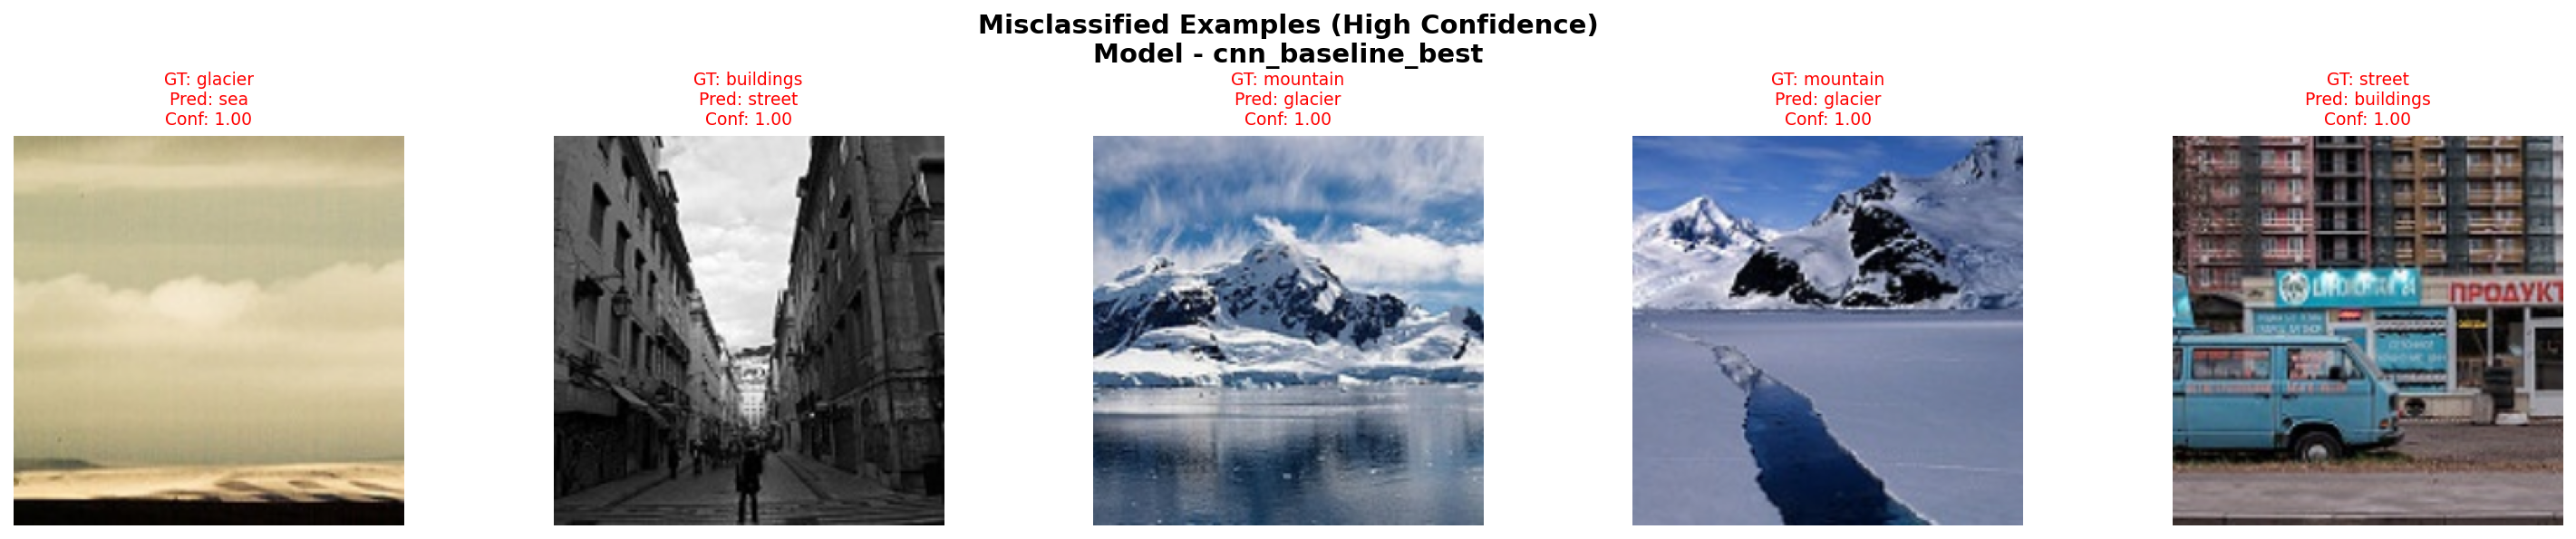

In [ ]:
# model
experiment_name = 'cnn_baseline_best'
model = LightweightCNN(num_classes=6, base_channels=32)
checkpoint = torch.load(f'/content/workspace/checkpoints/{experiment_name}.pth', map_location='cpu')
model.load_state_dict(checkpoint['model'])
model = model.to('cuda').eval()

# load history
history_path = os.path.join('/content/workspace/logs', f'{experiment_name.replace('_best','')}_history.json')
with open(history_path, 'r') as f:
    history = json.load(f)

# datset
test_dataset = IntelDataset('seg_test', data_dir, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# evaluate
all_preds, all_labels, all_imgs, all_probs = evaluate_full(model, test_loader, test_dataset.classes)
plot_history(history, experiment_name=experiment_name)
visualize_eval(
    all_preds, all_labels, all_imgs, all_probs,
    train_dataset.classes, experiment_name='cnn_baseline_best'
)
show_misclassified(all_imgs, all_preds, all_labels, all_probs, test_dataset.classes, experiment_name='cnn_baseline_best')